In [1]:
import numpy as np
import pandas as pd
import cv2
import sklearn

print(np.__version__)
print(pd.__version__)
print(cv2.__version__)
print(sklearn.__version__)

2.1.3
2.2.3
4.14.0
1.6.1


In [2]:
import cv2
import numpy as np
import os
import pandas as pd
import time

# PART A — Image Feature Extraction

In [6]:
from google.colab import files

f = files.upload()

Saving xnzhj3x8v4-1.zip to xnzhj3x8v4-1.zip


In [7]:
import zipfile

with zipfile.ZipFile("xnzhj3x8v4-1.zip", "r") as z:
    z.extractall("data")

In [8]:
os.listdir("data")

['448']

In [9]:
p = "data/448"

cp = os.path.join(p, "Cracks")
np_ = os.path.join(p, "NonCracks")

print(os.listdir(p))

['Cracks', 'NonCracks']


In [10]:
cf = os.listdir(cp)
nf = os.listdir(np_)

print("Cracks:", len(cf))
print("NonCracks:", len(nf))

Cracks: 200
NonCracks: 200


In [11]:
sz = (224, 224)
rows = []

for f in cf:
    im = cv2.imread(os.path.join(cp, f))
    im = cv2.resize(im, sz)
    g = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    e = cv2.Canny(g, 100, 200)

    rows.append([
        g.mean(),
        g.std(),
        np.mean(g < 50),
        np.mean(g > 200),
        np.mean(e > 0),
        1
    ])

for f in nf:
    im = cv2.imread(os.path.join(np_, f))
    im = cv2.resize(im, sz)
    g = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    e = cv2.Canny(g, 100, 200)

    rows.append([
        g.mean(),
        g.std(),
        np.mean(g < 50),
        np.mean(g > 200),
        np.mean(e > 0),
        0
    ])

df = pd.DataFrame(
    rows,
    columns=[
        "brightness",
        "contrast",
        "dark_ratio",
        "bright_ratio",
        "edge_density",
        "label"
    ]
)

print("Feature table:", df.shape)
df.head()

Feature table: (400, 6)


,brightness,contrast,dark_ratio,bright_ratio,edge_density,label
0,171.072505,30.362274,0.000419,0.153619,0.325454,1
1,110.477898,37.729265,0.042929,0.004385,0.369260,1
2,183.398856,22.235632,0.000000,0.228177,0.326212,1
3,127.686723,18.584136,0.000000,0.001096,0.256059,1
4,139.863680,34.191801,0.018595,0.027324,0.358956,1


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

x = df.drop("label", axis=1)
y = df["label"]

xtr, xte, ytr, yte = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000)
    )
}

for name, m in models.items():
    t1 = time.time()
    m.fit(xtr, ytr)
    train_time = time.time() - t1

    t1 = time.time()
    yp = m.predict(xte)
    pred_time = time.time() - t1

    print("\n", name)
    print("Accuracy :", accuracy_score(yte, yp))
    print("Precision:", precision_score(yte, yp, zero_division=0))
    print("Recall   :", recall_score(yte, yp, zero_division=0))
    print("F1 Score :", f1_score(yte, yp, zero_division=0))
    print("Train Time:", train_time)
    print("Predict Time:", pred_time)
    print("Confusion Matrix:")
    print(confusion_matrix(yte, yp))


 Random Forest
Accuracy : 0.95
Precision: 0.9285714285714286
Recall   : 0.975
F1 Score : 0.9512195121951219
Train Time: 0.4277162551879883
Predict Time: 0.03154182434082031
Confusion Matrix:
[[37  3]
 [ 1 39]]

 Logistic Regression
Accuracy : 0.9125
Precision: 0.8837209302325582
Recall   : 0.95
F1 Score : 0.9156626506024096
Train Time: 0.14545345306396484
Predict Time: 0.01962447166442871
Confusion Matrix:
[[35  5]
 [ 2 38]]


In [13]:
df.to_csv("image_features.csv", index=False)

print("Saved:", "image_features.csv")
print(df.shape)

Saved: image_features.csv
(400, 6)


# PART B — Text Data

In [16]:
import pandas as pd
import re

dfm = pd.read_csv("emails.csv")

print("Shape:", dfm.shape)
print(dfm.columns)
print(dfm.head())
print("\nClass distribution:")
print(dfm.iloc[:, -1].value_counts())

Shape: (5172, 3002)
Index(['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou',
       ...
       'connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military',
       'allowing', 'ff', 'dry', 'Prediction'],
      dtype='object', length=3002)
  Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   
2   Email 3    0   0    1    0    0   0    8    0    0  ...         0    0   
3   Email 4    0   5   22    0    5   1   51    2   10  ...         0    0   
4   Email 5    7   6   17    1    5   2   57    0    9  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  
2       0    0               0         0    

In [17]:
import zipfile
import os

with zipfile.ZipFile("emails.csv.zip", "r") as z:
    z.extractall("email_data")

print(os.listdir("email_data"))

['emails.csv']


In [18]:
dfm = pd.read_csv("email_data/emails.csv")

print("Shape:", dfm.shape)
print("Columns:", dfm.columns[:10].tolist(), "...", dfm.columns[-5:].tolist())
print(dfm.head())

Shape: (5172, 3002)
Columns: ['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou'] ... ['military', 'allowing', 'ff', 'dry', 'Prediction']
  Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   
2   Email 3    0   0    1    0    0   0    8    0    0  ...         0    0   
3   Email 4    0   5   22    0    5   1   51    2   10  ...         0    0   
4   Email 5    7   6   17    1    5   2   57    0    9  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  
2       0    0               0         0         0   0    0           0  
3       0    0               0         0         0   0    0           0  
4  

In [19]:
dfm = pd.read_csv("email_data/emails.csv")

x = dfm.drop(["Email No.", "Prediction"], axis=1)
y = dfm["Prediction"]

xtr, xte, ytr, yte = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print("Features:", x.shape[1])
print("Training:", xtr.shape)
print("Testing:", xte.shape)
print("Spam:", y.sum())
print("Non-spam:", (y == 0).sum())

Features: 3000
Training: (4137, 3000)
Testing: (1035, 3000)
Spam: 1500
Non-spam: 3672


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

for name, m in models.items():
    t1 = time.time()
    m.fit(xtr, ytr)
    train_time = time.time() - t1

    t1 = time.time()
    yp = m.predict(xte)
    pred_time = time.time() - t1

    print("\n", name)
    print("Accuracy :", accuracy_score(yte, yp))
    print("Precision:", precision_score(yte, yp, zero_division=0))
    print("Recall   :", recall_score(yte, yp, zero_division=0))
    print("F1 Score :", f1_score(yte, yp, zero_division=0))
    print("Train Time:", train_time)
    print("Predict Time:", pred_time)
    print("Confusion Matrix:")
    print(confusion_matrix(yte, yp))


 Random Forest
Accuracy : 0.9642512077294686
Precision: 0.933993399339934
Recall   : 0.9433333333333334
F1 Score : 0.9386401326699834
Train Time: 4.0272791385650635
Predict Time: 0.039048194885253906
Confusion Matrix:
[[715  20]
 [ 17 283]]

 Logistic Regression
Accuracy : 0.9826086956521739
Precision: 0.9577922077922078
Recall   : 0.9833333333333333
F1 Score : 0.9703947368421053
Train Time: 13.914368152618408
Predict Time: 0.07523131370544434
Confusion Matrix:
[[722  13]
 [  5 295]]


In [21]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

m = Pipeline([
    ("select", SelectKBest(chi2, k=1000)),
    ("model", LogisticRegression(max_iter=1000))
])

t1 = time.time()
m.fit(xtr, ytr)
train_time = time.time() - t1

t1 = time.time()
yp = m.predict(xte)
pred_time = time.time() - t1

print("Original Features:", x.shape[1])
print("Improved Features:", 1000)
print("Accuracy :", accuracy_score(yte, yp))
print("Precision:", precision_score(yte, yp, zero_division=0))
print("Recall   :", recall_score(yte, yp, zero_division=0))
print("F1 Score :", f1_score(yte, yp, zero_division=0))
print("Train Time:", train_time)
print("Predict Time:", pred_time)
print("Confusion Matrix:")
print(confusion_matrix(yte, yp))

Original Features: 3000
Improved Features: 1000
Accuracy : 0.9729468599033816
Precision: 0.9473684210526315
Recall   : 0.96
F1 Score : 0.9536423841059603
Train Time: 12.904584169387817
Predict Time: 0.043997764587402344
Confusion Matrix:
[[719  16]
 [ 12 288]]


# Part C comparison

In [22]:
res = pd.DataFrame({
    "Model": ["Original Logistic Regression", "Improved Logistic Regression"],
    "Features": [3000, 1000],
    "Accuracy": [0.9826, 0.9729],
    "Precision": [0.9578, 0.9474],
    "Recall": [0.9833, 0.9600],
    "F1": [0.9704, 0.9536],
    "Train Time": [13.9144, 12.9046],
    "Predict Time": [0.0752, 0.0440]
})

res

,Model,Features,Accuracy,Precision,Recall,F1,Train Time,Predict Time
0,Original Logistic Regression,3000,0.9826,0.9578,0.9833,0.9704,13.9144,0.0752
1,Improved Logistic Regression,1000,0.9729,0.9474,0.9600,0.9536,12.9046,0.0440


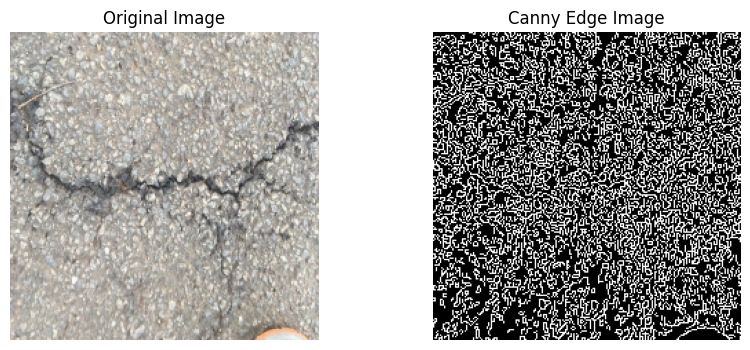

In [23]:
import matplotlib.pyplot as plt

f = cf[0]
im = cv2.imread(os.path.join(cp, f))
im = cv2.resize(im, sz)
g = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
e = cv2.Canny(g, 100, 200)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(e, cmap="gray")
plt.title("Canny Edge Image")
plt.axis("off")

plt.show()

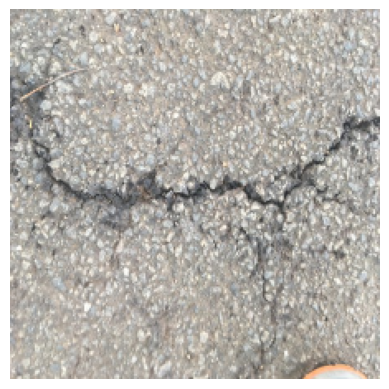

In [24]:
import matplotlib.pyplot as plt

f = cf[0]
im = cv2.imread(os.path.join(cp, f))
im = cv2.resize(im, sz)

plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [25]:
res.to_csv("model_comparison.csv", index=False)
df.to_csv("image_features.csv", index=False)

print("Saved: image_features.csv")
print("Saved: model_comparison.csv")


Saved: image_features.csv
Saved: model_comparison.csv


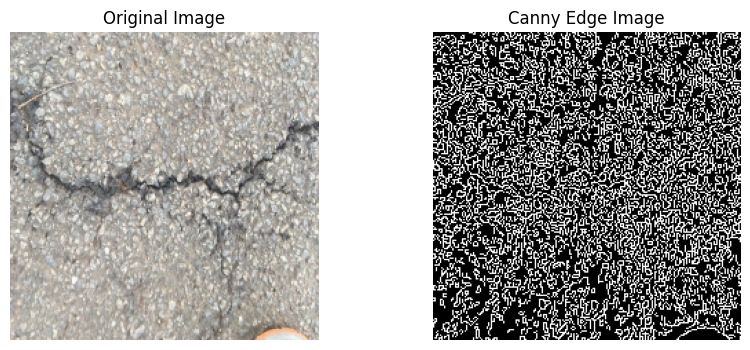

In [26]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(e, cmap="gray")
plt.title("Canny Edge Image")
plt.axis("off")

plt.savefig("canny_visualization.png", bbox_inches="tight")
plt.show()

In [27]:
pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "Improved Logistic Regression"],
    "Features": [3000, 3000, 1000],
    "Accuracy": [0.9643, 0.9826, 0.9729],
    "Precision": [0.9340, 0.9578, 0.9474],
    "Recall": [0.9433, 0.9833, 0.9600],
    "F1": [0.9386, 0.9704, 0.9536],
    "Train Time": [4.0273, 13.9144, 12.9046],
    "Predict Time": [0.0390, 0.0752, 0.0440]
})


,Model,Features,Accuracy,Precision,Recall,F1,Train Time,Predict Time
0,Random Forest,3000,0.9643,0.9340,0.9433,0.9386,4.0273,0.0390
1,Logistic Regression,3000,0.9826,0.9578,0.9833,0.9704,13.9144,0.0752
2,Improved Logistic Regression,1000,0.9729,0.9474,0.9600,0.9536,12.9046,0.0440
